# Pure Architecture Comparison: Baseline vs Knowledge Distillation

This notebook trains **3 student architectures** (none using DNABERT-2 pretrained layers) on human promoter binary classification, each in **baseline** (cross-entropy only) and **KD** (distillation from DNABERT-2 teacher) mode.

**Architectures:**
1. **4-Layer Pure Transformer** — standard BERT config (4 layers, 768 hidden, random init, NOT from DNABERT-2)
2. **4-Layer Pure CNN** — embedding + 4 Conv1d layers, no transformer at all
3. **Hybrid Pure** — 3-layer standard BERT (random init) + 1 Conv1d layer

**KD config:** α=0.3, T=3.0 (best from grid search)

**Setup:** Add teacher notebook output as Kaggle input. GPU T4 x 2, Internet ON.

**Estimated runtime:** ~10 hours (6 experiments)

In [1]:
!pip install transformers datasets accelerate scikit-learn einops

# Configuration & Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
import gc
import os
import json
import time
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    BertConfig,
    BertModel,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    TrainerCallback,
)
from transformers.modeling_outputs import SequenceClassifierOutput
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# ===== Constants =====
MODEL_NAME = "quietflamingo/dnabert2-no-flashattention"
MAX_LENGTH = 300
BATCH_SIZE = 16
NUM_EPOCHS = 10
SEED = 42
KD_ALPHA = 0.3      # best from grid search
KD_TEMPERATURE = 3.0 # best from grid search

# ===== Reproducibility =====
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
num_gpus = torch.cuda.device_count()
print(f"Device: {device}, GPUs: {num_gpus}")
for i in range(num_gpus):
    name = torch.cuda.get_device_name(i)
    mem = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f"  GPU {i}: {name} ({mem:.1f} GB)")

Device: cuda, GPUs: 2
  GPU 0: Tesla T4 (15.6 GB)
  GPU 1: Tesla T4 (15.6 GB)


# Load Dataset & Tokenize

In [3]:
print("Loading human promoter dataset...")
raw_dataset = load_dataset("InstaDeepAI/nucleotide_transformer_downstream_tasks")

def filter_promoter_all(example):
    return example["task"] == "promoter_all"

train_data_raw = raw_dataset["train"].filter(filter_promoter_all)
test_data_raw = raw_dataset["test"].filter(filter_promoter_all)

def prepare_data(example):
    return {"sequence": example["sequence"].upper(), "label": int(example["label"])}

train_data = train_data_raw.map(prepare_data)
test_data = test_data_raw.map(prepare_data)
print(f"Train: {len(train_data)}, Test: {len(test_data)}")

# Tokenize using DNABERT-2 tokenizer (needed so teacher & students share same input format)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

def tokenize_func(examples):
    return tokenizer(examples["sequence"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

tokenized_train = train_data.map(tokenize_func, batched=True)
tokenized_test = test_data.map(tokenize_func, batched=True)
tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
tokenized_train = tokenized_train.rename_column("label", "labels")
tokenized_test = tokenized_test.rename_column("label", "labels")

train_dataset = tokenized_train
eval_dataset = tokenized_test

VOCAB_SIZE = tokenizer.vocab_size
print(f"Tokenizer vocab size: {VOCAB_SIZE}")
print(f"Sample input_ids shape: {train_dataset[0]['input_ids'].shape}")

Loading human promoter dataset...


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

H3/train.parquet:   0%|          | 0.00/3.48M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/53276 [00:00<?, ? examples/s]

Map:   0%|          | 0/5920 [00:00<?, ? examples/s]

Tokenizer vocab size: 4096
Sample input_ids shape: torch.Size([300])


# Load Teacher Model (for KD experiments)

In [4]:
import glob
from safetensors.torch import load_file as load_safetensors
from transformers import AutoConfig
from transformers.dynamic_module_utils import get_class_from_dynamic_module

def find_teacher_model():
    base = "/kaggle/input"
    for filename in ["model.safetensors", "pytorch_model.bin"]:
        matches = glob.glob(f"{base}/**/lr_2e-05_results/checkpoint-4375/{filename}", recursive=True)
        if matches:
            return os.path.dirname(matches[0]), "best checkpoint (96.71%)"
    for filename in ["model.safetensors", "pytorch_model.bin"]:
        matches = glob.glob(f"{base}/**/human_promoter_model/{filename}", recursive=True)
        if matches:
            return os.path.dirname(matches[0]), "Phase 1 model (96.40%)"
    return None, None

teacher_path, teacher_desc = find_teacher_model()
if teacher_path is None:
    raise FileNotFoundError("Teacher model not found! Add teacher notebook output as Kaggle input.")

print(f"Found teacher: {teacher_desc}\nPath: {teacher_path}")

config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)
config.num_labels = 2
config.pad_token_id = tokenizer.pad_token_id

class_ref = config.auto_map["AutoModelForSequenceClassification"]
model_class = get_class_from_dynamic_module(class_ref, MODEL_NAME)
teacher_model = model_class(config)

weights_file = os.path.join(teacher_path, "model.safetensors")
if os.path.exists(weights_file):
    state_dict = load_safetensors(weights_file)
else:
    weights_file = os.path.join(teacher_path, "pytorch_model.bin")
    state_dict = torch.load(weights_file, map_location="cpu", weights_only=True)

teacher_model.load_state_dict(state_dict)
teacher_model.eval()
teacher_params = sum(p.numel() for p in teacher_model.parameters())
print(f"Teacher loaded: {teacher_params:,} params ({teacher_params/1e6:.1f}M)")

Found teacher: best checkpoint (96.71%)
Path: /kaggle/input/notebooks/sheikhrahatmahmud/ml-project-kaggle15916a635e/lr_2e-05_results/checkpoint-4375


bert_layers.py: 0.00B [00:00, ?B/s]

bert_padding.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/quietflamingo/dnabert2-no-flashattention:
- bert_padding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
A new version of the following files was downloaded from https://huggingface.co/quietflamingo/dnabert2-no-flashattention:
- bert_layers.py
- bert_padding.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/root/.cache/huggingface/modules/transformers_modules/quietflamingo/dnabert2_hyphen_no_hyphen_flashattention/813031b2bf86d9e960a027e2734c908009f31601/bert_layers.py:123: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


Teacher loaded: 117,070,082 params (117.1M)


# Define 3 Pure Student Architectures + Trainer Components

In [5]:
# =====================================================================
# ARCHITECTURE 1: 4-Layer Pure Transformer (standard BERT, NOT DNABERT-2)
# =====================================================================
def get_pure_transformer_4L():
    """4-layer BERT from scratch — standard config, no DNABERT-2 layers."""
    config = BertConfig(
        vocab_size=VOCAB_SIZE,
        hidden_size=768,
        num_hidden_layers=4,
        num_attention_heads=12,
        intermediate_size=3072,
        max_position_embeddings=512,
        num_labels=2,
    )
    return BertForSequenceClassification(config)


# =====================================================================
# ARCHITECTURE 2: 4-Layer Pure CNN (no transformer at all)
# =====================================================================
class PureCNN4Layer(nn.Module):
    """4 Conv1d layers over learned embeddings — zero transformer components."""
    def __init__(self, vocab_size, embed_dim=256, num_filters=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        # 4 CNN layers with decreasing kernel sizes (captures motifs at multiple scales)
        self.conv1 = nn.Conv1d(embed_dim, num_filters, kernel_size=15, padding=7)
        self.bn1 = nn.BatchNorm1d(num_filters)
        self.conv2 = nn.Conv1d(num_filters, num_filters, kernel_size=9, padding=4)
        self.bn2 = nn.BatchNorm1d(num_filters)
        self.conv3 = nn.Conv1d(num_filters, num_filters, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(num_filters)
        self.conv4 = nn.Conv1d(num_filters, num_filters, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(num_filters)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(0.1)
        self.classifier = nn.Linear(num_filters, 2)

    def forward(self, input_ids, attention_mask=None, labels=None):
        x = self.embedding(input_ids)            # [B, L, embed_dim]
        x = x.permute(0, 2, 1)                   # [B, embed_dim, L]
        x = F.relu(self.bn1(self.conv1(x)))       # [B, 256, L]
        x = F.relu(self.bn2(self.conv2(x)))       # [B, 256, L]
        x = F.relu(self.bn3(self.conv3(x)))       # [B, 256, L]
        x = F.relu(self.bn4(self.conv4(x)))       # [B, 256, L]
        x = self.pool(x).squeeze(-1)              # [B, 256]
        x = self.dropout(x)
        logits = self.classifier(x)               # [B, 2]
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return SequenceClassifierOutput(loss=loss, logits=logits)


# =====================================================================
# ARCHITECTURE 3: Hybrid Pure — 3L Transformer (NOT DNABERT-2) + 1L CNN
# =====================================================================
class HybridPure3T1C(nn.Module):
    """3-layer standard BERT (random init) + 1 Conv1d head."""
    def __init__(self, vocab_size):
        super().__init__()
        config = BertConfig(
            vocab_size=vocab_size,
            hidden_size=768,
            num_hidden_layers=3,
            num_attention_heads=12,
            intermediate_size=3072,
            max_position_embeddings=512,
        )
        self.bert = BertModel(config)
        self.conv = nn.Conv1d(768, 128, kernel_size=9, padding=4)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.classifier = nn.Linear(128, 2)

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask)
        x = outputs.last_hidden_state.permute(0, 2, 1)  # [B, 768, L]
        x = F.relu(self.conv(x))                         # [B, 128, L]
        x = self.pool(x).squeeze(-1)                     # [B, 128]
        logits = self.classifier(x)
        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)
        return SequenceClassifierOutput(loss=loss, logits=logits)


# =====================================================================
# DISTILLATION TRAINER
# =====================================================================
class DistillationTrainer(Trainer):
    def __init__(self, *args, teacher_model=None, alpha=0.3, temperature=3.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.teacher_model = teacher_model.to(self.args.device)
        self.alpha = alpha
        self.temperature = temperature
        self.teacher_model.eval()

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs_student = model(**inputs)
        student_logits = outputs_student.logits
        labels = inputs.get("labels")

        with torch.no_grad():
            outputs_teacher = self.teacher_model(**inputs)
            teacher_logits = outputs_teacher.logits

        soft_loss = nn.KLDivLoss(reduction="batchmean")(
            F.log_softmax(student_logits / self.temperature, dim=-1),
            F.softmax(teacher_logits / self.temperature, dim=-1)
        ) * (self.temperature ** 2)

        hard_loss = F.cross_entropy(student_logits, labels)
        loss = self.alpha * hard_loss + (1 - self.alpha) * soft_loss
        return (loss, outputs_student) if return_outputs else loss


# =====================================================================
# HELPERS
# =====================================================================
def compute_metrics(pred):
    labels = pred.label_ids
    logits = pred.predictions[0] if isinstance(pred.predictions, tuple) else pred.predictions
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
    }

class ProgressCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            print(f"Step {state.global_step}: {logs}", flush=True)
    def on_epoch_begin(self, args, state, control, **kwargs):
        print(f"\n{'='*60}\nEpoch {int(state.epoch) + 1}/{args.num_train_epochs}\n{'='*60}", flush=True)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


# =====================================================================
# MODEL SIZE PREVIEW
# =====================================================================
print("="*70)
print("MODEL SIZE COMPARISON")
print("="*70)
print(f"{'Model':<30} {'Parameters':>15} {'Size (M)':>10} {'Compression':>12}")
print("-"*70)
print(f"{'Teacher (DNABERT-2)':<30} {teacher_params:>15,} {teacher_params/1e6:>10.1f} {'1.0x':>12}")

preview_models = {
    "4L-Pure-Transformer": get_pure_transformer_4L(),
    "4L-Pure-CNN": PureCNN4Layer(VOCAB_SIZE),
    "Hybrid-Pure-3T1C": HybridPure3T1C(VOCAB_SIZE),
}
for name, m in preview_models.items():
    p = count_parameters(m)
    print(f"{name:<30} {p:>15,} {p/1e6:>10.1f} {teacher_params/p:>11.1f}x")
del preview_models
gc.collect()
print("="*70)

MODEL SIZE COMPARISON
Model                               Parameters   Size (M)  Compression
----------------------------------------------------------------------
Teacher (DNABERT-2)                117,070,082      117.1         1.0x
4L-Pure-Transformer                 32,485,634       32.5         3.6x
4L-Pure-CNN                          3,149,314        3.1        37.2x
Hybrid-Pure-3T1C                    26,281,346       26.3         4.5x


# Run All 6 Experiments: 3 Architectures × (Baseline + KD)

In [6]:
# ===== EXPERIMENT DEFINITIONS =====
# Each tuple: (name, model_factory, is_custom_module)
# is_custom_module=True means we must set remove_unused_columns=False for HF Trainer

architectures = [
    ("4L-Pure-Transformer", get_pure_transformer_4L, False),
    ("4L-Pure-CNN",         lambda: PureCNN4Layer(VOCAB_SIZE), True),
    ("Hybrid-Pure-3T1C",    lambda: HybridPure3T1C(VOCAB_SIZE), True),
]

modes = ["baseline", "kd"]  # baseline = CE only, kd = distillation

all_results = {}
total_exps = len(architectures) * len(modes)
exp_idx = 0

for arch_name, model_fn, is_custom in architectures:
    for mode in modes:
        exp_idx += 1
        run_key = f"{arch_name}_{mode}"

        print(f"\n{'#'*70}")
        print(f"# Experiment {exp_idx}/{total_exps}: {arch_name} — {mode.upper()}")
        print(f"{'#'*70}")

        # Clear GPU
        gc.collect()
        torch.cuda.empty_cache()

        # Reset seed
        random.seed(SEED)
        np.random.seed(SEED)
        torch.manual_seed(SEED)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED)

        # Fresh student
        student = model_fn()
        n_params = count_parameters(student)
        print(f"Student: {arch_name}, Params: {n_params:,} ({n_params/1e6:.1f}M)")
        print(f"Mode: {mode} | {'α='+str(KD_ALPHA)+', T='+str(KD_TEMPERATURE) if mode=='kd' else 'CE only'}")

        output_dir = f"/kaggle/working/{run_key}"
        args = TrainingArguments(
            output_dir=output_dir,
            num_train_epochs=NUM_EPOCHS,
            per_device_train_batch_size=BATCH_SIZE,
            per_device_eval_batch_size=BATCH_SIZE,
            fp16=True,
            logging_steps=100,
            eval_strategy="epoch",
            save_strategy="epoch",
            load_best_model_at_end=True,
            metric_for_best_model="eval_accuracy",
            greater_is_better=True,
            save_total_limit=1,
            report_to="none",
            remove_unused_columns=not is_custom,
            warmup_ratio=0.1,
            weight_decay=0.01,
            lr_scheduler_type="cosine",
            learning_rate=2e-5,
        )

        start_time = time.time()

        if mode == "kd":
            trainer = DistillationTrainer(
                model=student,
                teacher_model=teacher_model,
                alpha=KD_ALPHA,
                temperature=KD_TEMPERATURE,
                args=args,
                train_dataset=train_dataset,
                eval_dataset=eval_dataset,
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=3), ProgressCallback()],
            )
        else:
            trainer = Trainer(
                model=student,
                args=args,
                train_dataset=train_dataset,
                eval_dataset=eval_dataset,
                compute_metrics=compute_metrics,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=3), ProgressCallback()],
            )

        print("Starting training...", flush=True)
        trainer.train()
        train_time = time.time() - start_time

        metrics = trainer.evaluate()
        print(f"\n--- {run_key} Results ---")
        print(f"  Accuracy:  {metrics['eval_accuracy']:.2%}")
        print(f"  F1 Score:  {metrics['eval_f1']:.4f}")
        print(f"  Precision: {metrics['eval_precision']:.4f}")
        print(f"  Recall:    {metrics['eval_recall']:.4f}")
        print(f"  Loss:      {metrics['eval_loss']:.4f}")
        print(f"  Time:      {train_time/60:.1f} min")

        # Save model
        save_dir = f"/kaggle/working/{run_key}_final"
        os.makedirs(save_dir, exist_ok=True)
        if is_custom:
            torch.save(student.state_dict(), os.path.join(save_dir, "model.pt"))
        else:
            student.save_pretrained(save_dir)

        all_results[run_key] = {
            "architecture": arch_name,
            "mode": mode,
            "accuracy": metrics["eval_accuracy"],
            "f1": metrics["eval_f1"],
            "precision": metrics["eval_precision"],
            "recall": metrics["eval_recall"],
            "loss": metrics["eval_loss"],
            "params": n_params,
            "compression": teacher_params / n_params,
            "train_time_min": round(train_time / 60, 1),
        }

        # Checkpoint results after each experiment
        with open("/kaggle/working/pure_arch_results.json", "w") as f:
            json.dump(all_results, f, indent=2)
        print(f"  Results saved ({len(all_results)}/{total_exps} done)")

        del trainer, student
        gc.collect()
        torch.cuda.empty_cache()

print(f"\n{'='*70}")
print(f"ALL {total_exps} EXPERIMENTS COMPLETED!")
print(f"{'='*70}")


######################################################################
# Experiment 1/6: 4L-Pure-Transformer — BASELINE
######################################################################
Student: 4L-Pure-Transformer, Params: 32,485,634 (32.5M)
Mode: baseline | CE only


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting training...

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.701147,0.784741,0.837331,0.811730,0.963341,0.701351
2,0.588742,0.600215,0.872297,0.878496,0.837830,0.923311
3,0.535146,0.689048,0.865541,0.849527,0.964378,0.759122
4,0.452458,0.536154,0.892905,0.896066,0.870382,0.923311
5,0.441163,0.483036,0.904561,0.900860,0.937203,0.867230
6,0.355348,0.462479,0.916216,0.914187,0.936879,0.892568
7,0.284870,0.529470,0.908277,0.902566,0.962495,0.849662
8,0.247520,0.500547,0.917399,0.914794,0.944584,0.886824
9,0.219536,0.517149,0.919764,0.917834,0.940447,0.896284
10,0.227485,0.524006,0.919426,0.917517,0.939780,0.896284


...

Step 13400: {'loss': 0.07266090393066406, 'grad_norm': 10.886466979980469, 'learning_rate': 2.234150770423518e-06, 'epoch': 8.048048048048049}
Step 13500: {'loss': 0.07040414810180665, 'grad_norm': 6.59232759475708, 'learning_rate': 2.103785427330739e-06, 'epoch': 8.108108108108109}
Step 13600: {'loss': 0.06943385124206543, 'grad_norm': 2.515432357788086, 'learning_rate': 1.976890562153623e-06, 'epoch': 8.168168168168169}
Step 13700: {'loss': 0.07463819026947022, 'grad_norm': 4.6076860427856445, 'learning_rate': 1.8535219466576327e-06, 'epoch': 8.228228228228229}
Step 13800: {'loss': 0.07001705169677734, 'grad_norm': 11.52454662322998, 'learning_rate': 1.7337338027805907e-06, 'epoch': 8.288288288288289}
Step 13900: {'loss': 0.07294329643249511, 'grad_norm': 8.700740814208984, 'learning_rate': 1.6175787788014974e-06, 'epoch': 8.348348348348349}
Step 14000: {'loss': 0.07057341098785401, 'grad_norm': 5.06351375579834, 'learning_rate': 1.505107926201007e-06, 'epoch': 8.408408408408409}
Ste

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step 15000: {'loss': 0.06959423542022705, 'grad_norm': 3.4668216705322266, 'learning_rate': 5.930756896005707e-07, 'epoch': 9.00900900900901}
Step 15100: {'loss': 0.06809958934783936, 'grad_norm': 1.1921204328536987, 'learning_rate': 5.240224277500827e-07, 'epoch': 9.06906906906907}
Step 15200: {'loss': 0.06998855113983155, 'grad_norm': 3.640509843826294, 'learning_rate': 4.591339679818041e-07, 'epoch': 9.12912912912913}
Step 15300: {'loss': 0.06801877975463867, 'grad_norm': 5.832231521606445, 'learning_rate': 3.984388295266284e-07, 'epoch': 9.18918918918919}
Step 15400: {'loss': 0.07153835773468017, 'grad_norm': 5.167988300323486, 'learning_rate': 3.4196368860208495e-07, 'epoch': 9.24924924924925}
Step 15500: {'loss': 0.07110305309295654, 'grad_norm': 10.14139461517334, 'learning_rate': 2.897333666878299e-07, 'epoch': 9.30930930930931}
Step 15600: {'loss': 0.07345804691314697, 'grad_norm': 1.779079794883728, 'learning_rate': 2.4177081961631264e-07, 'epoch': 9.36936936936937}
Step 1570

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step 16650: {'eval_loss': 0.12275505810976028, 'eval_accuracy': 0.9285472972972973, 'eval_f1': 0.9275064267352185, 'eval_precision': 0.9412173913043478, 'eval_recall': 0.9141891891891892, 'eval_runtime': 77.5587, 'eval_samples_per_second': 76.329, 'eval_steps_per_second': 2.385, 'epoch': 10.0}

--- Hybrid-Pure-3T1C_kd Results ---
  Accuracy:  92.85%
  F1 Score:  0.9275
  Precision: 0.9412
  Recall:    0.9142
  Loss:      0.1228
  Time:      181.1 min
  Results saved (6/6 done)

ALL 6 EXPERIMENTS COMPLETED!


# Results Summary & Visualization

PURE ARCHITECTURE RESULTS: BASELINE vs KNOWLEDGE DISTILLATION
Run                            Mode         Accuracy       F1     Params   Compress     Time
--------------------------------------------------------------------------------------------------------------
Teacher (DNABERT-2)            ---           96.71%      ---    117.1M       1.0x      ---
--------------------------------------------------------------------------------------------------------------
4L-Pure-Transformer            baseline      91.98%   0.9178     32.5M       3.6x   98.1m
4L-Pure-Transformer            kd            93.01%   0.9284     32.5M       3.6x  195.8m
4L-Pure-CNN                    baseline      83.83%   0.8369      3.1M      37.2x    9.3m
4L-Pure-CNN                    kd            84.83%   0.8441      3.1M      37.2x  107.5m
Hybrid-Pure-3T1C               baseline      91.84%   0.9174     26.3M       4.5x   82.7m
Hybrid-Pure-3T1C               kd            92.85%   0.9275     26.3M       4.5x 

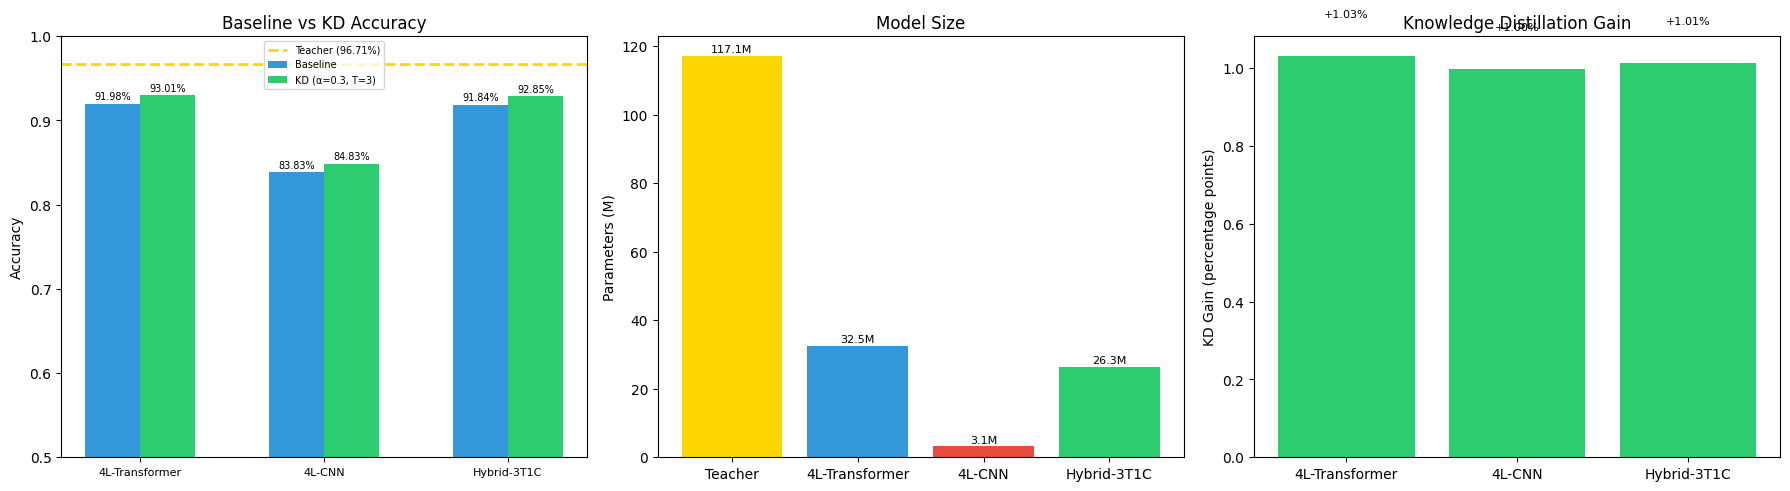

Charts saved to /kaggle/working/pure_arch_results.png
Results saved to /kaggle/working/pure_arch_results.json


In [7]:
import matplotlib.pyplot as plt

TEACHER_ACCURACY = 0.9671

# ===== FULL RESULTS TABLE =====
print("="*110)
print("PURE ARCHITECTURE RESULTS: BASELINE vs KNOWLEDGE DISTILLATION")
print("="*110)
print(f"{'Run':<30} {'Mode':<10} {'Accuracy':>10} {'F1':>8} {'Params':>10} {'Compress':>10} {'Time':>8}")
print("-"*110)
print(f"{'Teacher (DNABERT-2)':<30} {'---':<10} {TEACHER_ACCURACY:>9.2%} {'---':>8} {teacher_params/1e6:>8.1f}M {'1.0x':>10} {'---':>8}")
print("-"*110)
for key, res in all_results.items():
    print(f"{res['architecture']:<30} {res['mode']:<10} {res['accuracy']:>9.2%} {res['f1']:>8.4f} {res['params']/1e6:>8.1f}M {res['compression']:>9.1f}x {res['train_time_min']:>6.1f}m")
print("="*110)

# ===== KD GAIN TABLE =====
print(f"\n{'='*70}")
print("KNOWLEDGE DISTILLATION GAIN (KD accuracy - Baseline accuracy)")
print(f"{'='*70}")
arch_names = ["4L-Pure-Transformer", "4L-Pure-CNN", "Hybrid-Pure-3T1C"]
for arch in arch_names:
    base_key = f"{arch}_baseline"
    kd_key = f"{arch}_kd"
    if base_key in all_results and kd_key in all_results:
        base_acc = all_results[base_key]["accuracy"]
        kd_acc = all_results[kd_key]["accuracy"]
        gain = kd_acc - base_acc
        sign = "+" if gain >= 0 else ""
        print(f"  {arch:<25} Baseline={base_acc:.2%}, KD={kd_acc:.2%}, Gain={sign}{gain:.2%}")
print(f"{'='*70}")

# ===== CHART: Baseline vs KD per architecture =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Accuracy comparison
x = np.arange(len(arch_names))
width = 0.3
base_accs = [all_results.get(f"{a}_baseline", {}).get("accuracy", 0) for a in arch_names]
kd_accs = [all_results.get(f"{a}_kd", {}).get("accuracy", 0) for a in arch_names]
short_names = ["4L-Transformer", "4L-CNN", "Hybrid-3T1C"]

bars1 = axes[0].bar(x - width/2, base_accs, width, label="Baseline", color="#3498db")
bars2 = axes[0].bar(x + width/2, kd_accs, width, label="KD (α=0.3, T=3)", color="#2ecc71")
axes[0].axhline(y=TEACHER_ACCURACY, color="gold", linestyle="--", linewidth=2, label=f"Teacher ({TEACHER_ACCURACY:.2%})")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Baseline vs KD Accuracy")
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_names, fontsize=8)
axes[0].legend(fontsize=7)
axes[0].set_ylim(0.5, 1.0)
for bars in [bars1, bars2]:
    for bar in bars:
        if bar.get_height() > 0:
            axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{bar.get_height():.2%}", ha="center", fontsize=7)

# 2. Model sizes
all_names = ["Teacher"] + short_names
all_params_m = [teacher_params/1e6] + [all_results.get(f"{a}_baseline", {}).get("params", 0)/1e6 for a in arch_names]
colors = ["gold", "#3498db", "#e74c3c", "#2ecc71"]
bars3 = axes[1].bar(all_names, all_params_m, color=colors)
axes[1].set_ylabel("Parameters (M)")
axes[1].set_title("Model Size")
for bar, p in zip(bars3, all_params_m):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{p:.1f}M", ha="center", fontsize=8)

# 3. KD Gain
gains = [kd_accs[i] - base_accs[i] for i in range(len(arch_names))]
bar_colors = ["#2ecc71" if g >= 0 else "#e74c3c" for g in gains]
bars4 = axes[2].bar(short_names, [g*100 for g in gains], color=bar_colors)
axes[2].set_ylabel("KD Gain (percentage points)")
axes[2].set_title("Knowledge Distillation Gain")
axes[2].axhline(y=0, color="black", linewidth=0.5)
for bar, g in zip(bars4, gains):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f"{g:+.2%}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("/kaggle/working/pure_arch_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Charts saved to /kaggle/working/pure_arch_results.png")

# Save final JSON
with open("/kaggle/working/pure_arch_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print("Results saved to /kaggle/working/pure_arch_results.json")